In [19]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))


In [20]:
import torch

from src.datasets import get_dataloaders
from src.models import ResNet18Classifier
from src.embedding import extract_embeddings

In [50]:
result = get_dataloaders(DATA_DIR, batch_size=32)

print(type(result))
print(len(result))

<class 'tuple'>
4


In [34]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

DATA_DIR = "/home/divye/Desktop/cnn/data/2750"

train_loader, val_loader, classes, class_to_idx = get_dataloaders(
    DATA_DIR,
    batch_size=32
)

In [51]:
model = ResNet18Classifier(
    num_classes=len(classes)
)

model.load_state_dict(
    torch.load(
        "../checkpoints/resnet18_best.pt",
        map_location=device
    )
)

model.to(device)
model.eval()

ResNet18Classifier(
  (model): ResNet(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1

In [26]:
train_embeddings, train_labels = extract_embeddings(
    model,
    train_loader,
    device
)

val_embeddings, val_labels = extract_embeddings(
    model,
    
    val_loader,
    device
)

print(train_embeddings.shape)
print(val_embeddings.shape)

torch.Size([21600, 512])
torch.Size([5400, 512])


In [52]:
from src.similarity import cosine_similarity

image1 = val_embeddings[0].unsqueeze(0)
image2 = val_embeddings[1].unsqueeze(0)

score = cosine_similarity(
    image1,
    image2
)

print(score.item())

0.6379440426826477


In [36]:
import importlib
import src.datasets

importlib.reload(src.datasets)

from src.datasets import get_dataloaders

In [32]:
from src.embedding import extract_embeddings
from src.datasets import get_dataloaders

DATA_DIR = "/home/divye/Desktop/cnn/data/2750"
train_loader, val_loader, classes, class_to_idx = get_dataloaders(
    DATA_DIR,
    batch_size=32
)
train_embeddings, train_labels = extract_embeddings(
    model,
    train_loader,
    device
)

val_embeddings, val_labels = extract_embeddings(
    model,
    val_loader,
    device
)

print(train_embeddings.shape)
print(val_embeddings.shape)

torch.Size([21600, 512])
torch.Size([5400, 512])


In [41]:
from src.change_pairs import create_real_pairs

In [43]:
pair1, pair2, labels, idx1, idx2 = create_real_pairs(
    val_embeddings,
    val_labels,
    num_pairs=5000
)

In [44]:
from src.similarity import cosine_similarity

scores = cosine_similarity(pair1, pair2)

print(scores.min())
print(scores.max())
print(scores.mean())

tensor(0.1944)
tensor(0.9974)
tensor(0.6373)


In [45]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

similarity = scores.numpy()

fpr, tpr, thresholds = roc_curve(
    labels.numpy(),
    -similarity
)

roc_auc = auc(fpr, tpr)

print("ROC AUC =", roc_auc)

ROC AUC = 0.97141136


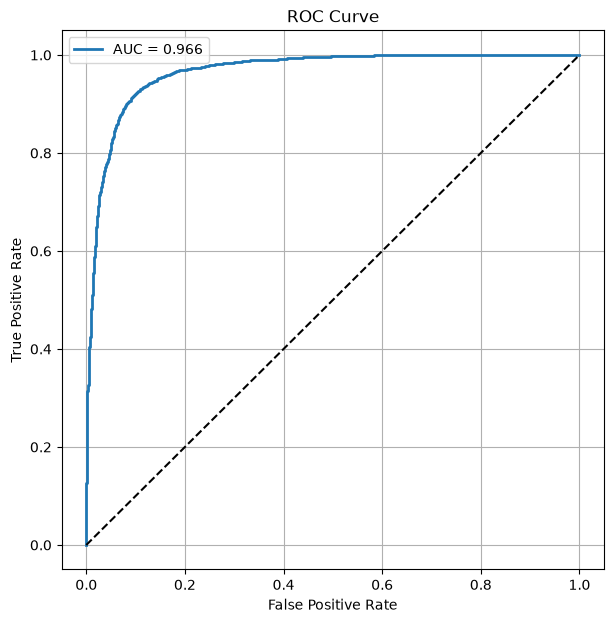

In [ ]:
plt.figure(figsize=(7,7))

plt.plot(
    fpr,
    tpr,
    linewidth=2,
    label=f"AUC = {roc_auc:.3f}"
)

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.grid(True)

plt.show()

In [46]:
import numpy as np

best_idx = np.argmax(tpr - fpr)

threshold = thresholds[best_idx]

print("Threshold =", threshold)

Threshold = -0.6167320609092712


In [48]:
predicted_change = similarity < (-threshold)

print(predicted_change[:20])


[False False False False False False False False  True False False False
 False False False False False  True False False]
